In [74]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from sklearn.cluster import KMeans

In [75]:
image_as_array = mpimg.imread("dog_image.jpeg")
image_as_array.shape
(h, w, c) = image_as_array.shape
print(f"Height: {h}px\nWidth: {w}px")

Height: 400px
Width: 600px


In [76]:
reshaped_imaged_array = image_as_array.reshape(h * w, c)
reshaped_imaged_array

array([[ 85,  81,  69],
       [ 85,  81,  69],
       [ 84,  80,  68],
       ...,
       [118, 126,  14],
       [117, 126,   9],
       [117, 127,   5]], shape=(240000, 3), dtype=uint8)

In [77]:
model = KMeans(n_clusters=6)
labels = model.fit_predict(reshaped_imaged_array)

labels

array([3, 3, 3, ..., 2, 2, 2], shape=(240000,), dtype=int32)

In [78]:
rgb_codes = model.cluster_centers_.round(0).astype(int)

In [79]:
k_values = [4, 10, 25, 50]
images = []
for k in k_values:
    model = KMeans(n_clusters=k)
    labels = model.fit_predict(reshaped_imaged_array)
    rgb_codes = model.cluster_centers_.round(0).astype(int)
    quantized_image = np.reshape(rgb_codes[labels], (h, w, c))
    images.append(quantized_image)
    
    

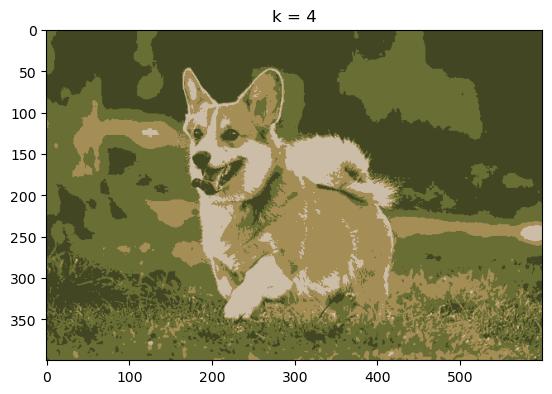

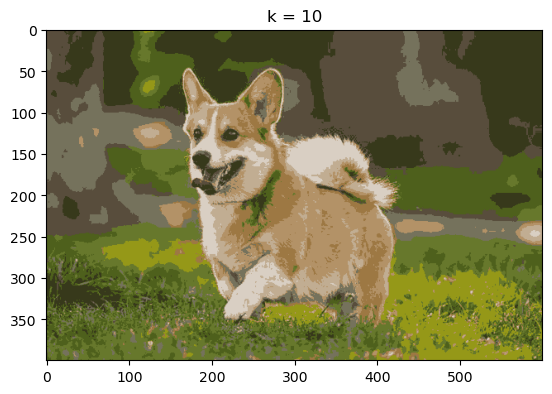

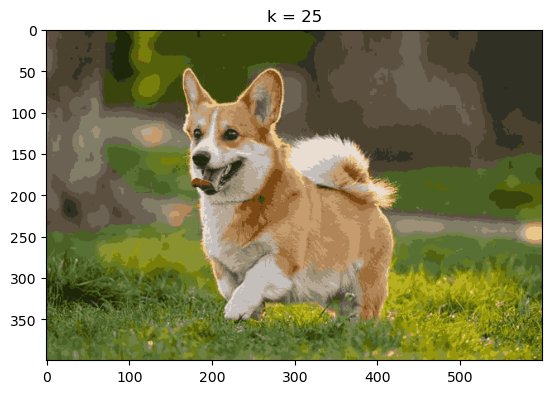

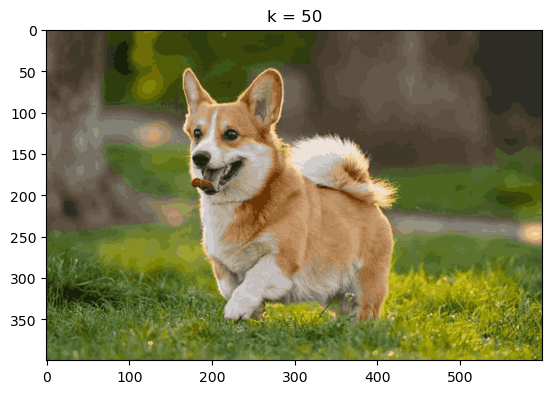

In [80]:
for image, k in zip(images, k_values):
    plt.title(f'k = {k}')
    plt.imshow(image)
    plt.show()
